In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import scipy.stats as st 


### Theory

The Bayes' rule based calculation is given by the following equation,

$$ P(\text{User}|+)=\frac{P(+|\text{User}).P(\text{User})}{P(+)}\\ = 
\frac{P(+|\text{User}).P(\text{User})}{P(+|\text{User}).P(\text{User})+P(+|\text{Non-user}).P(\text{Non-user})} $$

Here,

$P(\text{User}) = \text{Prevelance rate}$<br>
$P(\text{Non-user}) = 1-\text{Prevelance rate}$<br>
$P(+|\text{User})=\text{Sensitivity}$<br>
$P(-|\text{Non-user})=\text{Specificity}$<br>
$P(+|\text{Non-user})=1-\text{Specificity}$

In [2]:
def drug_user(prob_th=0.5,sensitivity=0.99,specificity=0.99,prevelance=0.01,verbose=True):
    p_user= prevelance
    p_nonuser=1-prevelance
    p_pos_user=sensitivity
    p_neg_user=specificity
    p_pos_nonuser=1-specificity
    num=p_pos_user*p_user
    den=p_pos_user*p_user+p_pos_nonuser*p_nonuser
    prob=num/den

    if verbose:
        if prob>prob_th:
            print("the test taker could be a user")
        else:
            print("the test taker may not be a user")
    return prob

In [3]:
p=drug_user(prob_th=0.5,sensitivity=0.97,specificity=0.95,verbose=True,prevelance=0.005)
print("probabiliity of being a drug user is  ",round(p,3))

the test taker may not be a user
probabiliity of being a drug user is   0.089


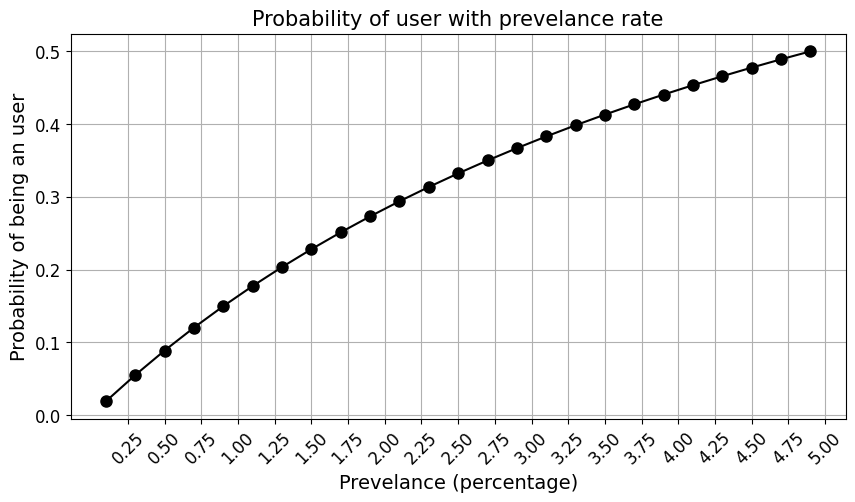

In [6]:
ps=[]
pres=[]
for pre in [i*0.001 for i in range(1,51,2)]:
    pres.append(pre*100)
    p=drug_user(prob_th=0.5,sensitivity=0.97,specificity=0.95,verbose=False,prevelance=pre)
    ps.append(p)

plt.figure(figsize=(10,5))
plt.title("Probability of user with prevelance rate",fontsize=15)
plt.plot(pres,ps,color='k',marker='o',markersize=8)
plt.grid(True)
plt.xlabel("Prevelance (percentage)",fontsize=14)
plt.ylabel("Probability of being an user",fontsize=14)
plt.xticks([i*0.25 for i in range(1,21)],fontsize=12,rotation=45)
plt.yticks(fontsize=12)
plt.show()


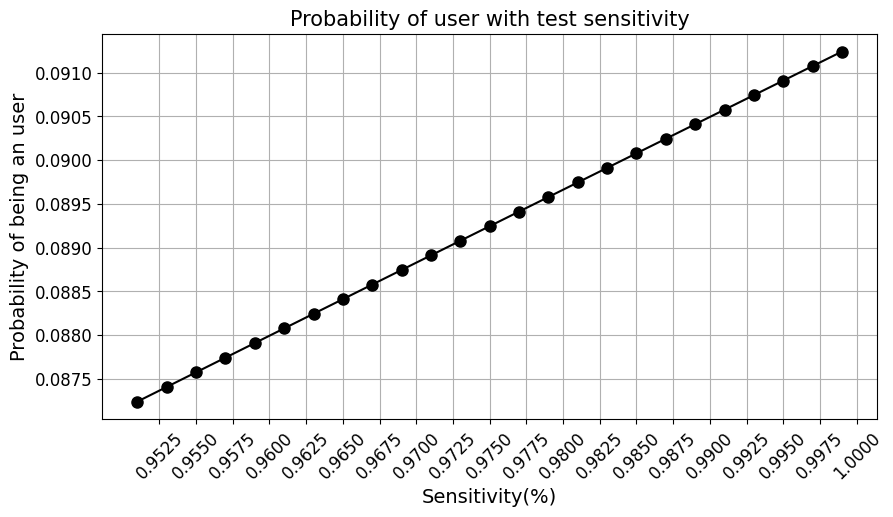

In [7]:
ps = []
sens = []
for sen in [i*0.001+0.95 for i in range(1,50,2)]:
    sens.append(sen)
    p = drug_user(prob_th=0.5,sensitivity=sen,specificity=0.95,prevelance=0.005,verbose=False)
    ps.append(p)

plt.figure(figsize=(10,5))
plt.title("Probability of user with test sensitivity",fontsize=15)
plt.plot(sens,ps,color='k',marker='o',markersize=8)
plt.grid(True)
plt.xlabel("Sensitivity(%)",fontsize=14)
plt.ylabel("Probability of being an user",fontsize=14)
plt.xticks([0.95+i*0.0025 for i in range(1,21)],fontsize=12,rotation=45)
plt.yticks(fontsize=12)
plt.show()

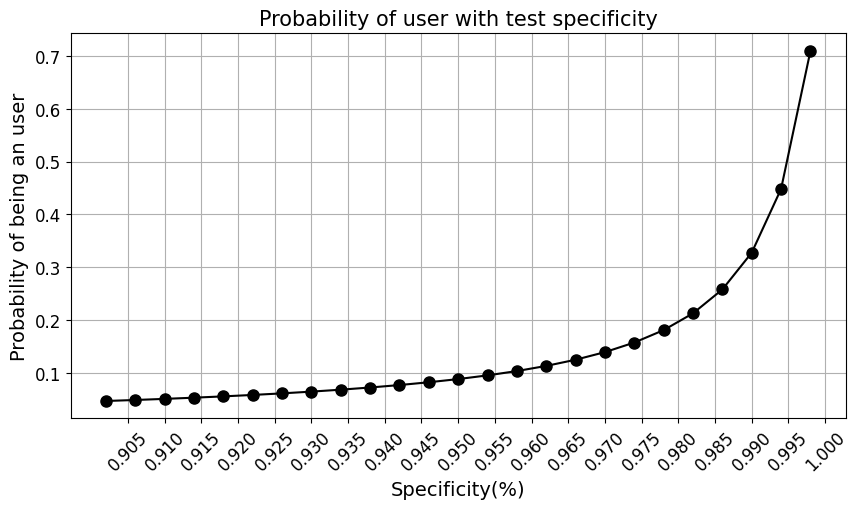

In [8]:
ps = []
spes = []
for spe in [i*0.002+0.9 for i in range(1,50,2)]:
    spes.append(spe)
    p = drug_user(prob_th=0.5,sensitivity=0.97,specificity=spe,prevelance=0.005,verbose=False)
    ps.append(p)

plt.figure(figsize=(10,5))
plt.title("Probability of user with test specificity",fontsize=15)
plt.plot(spes,ps,color='k',marker='o',markersize=8)
plt.grid(True)
plt.xlabel("Specificity(%)",fontsize=14)
plt.ylabel("Probability of being an user",fontsize=14)
plt.xticks([0.9+i*0.005 for i in range(1,21)],fontsize=12,rotation=45)
plt.yticks(fontsize=12)
plt.show()

In [9]:
p1 = drug_user(prob_th=0.5,sensitivity=0.97,specificity=0.95,prevelance=0.005)
print("Probability of the test-taker being a drug user, in the first round of test, is:",round(p1,3))
print()
p2 = drug_user(prob_th=0.5,sensitivity=0.97,specificity=0.95,prevelance=p1)
print("Probability of the test-taker being a drug user, in the second round of test, is:",round(p2,3))
print()
p3 = drug_user(prob_th=0.5,sensitivity=0.97,specificity=0.95,prevelance=p2)
print("Probability of the test-taker being a drug user, in the third round of test, is:",round(p3,3))

the test taker may not be a user
Probability of the test-taker being a drug user, in the first round of test, is: 0.089

the test taker could be a user
Probability of the test-taker being a drug user, in the second round of test, is: 0.654

the test taker could be a user
Probability of the test-taker being a drug user, in the third round of test, is: 0.973
